In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> (64, 32, 32)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> (128, 16, 16)
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# -> (256, 8, 8)
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),# -> (512, 4, 4)
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # -> (256, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # -> (128, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # -> (64, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),     # -> (3, 128, 128)
            nn.Sigmoid()  # To output values between 0 and 1
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        enc = self.encoder(x)
        enc = enc.view(x.size(0), -1)
        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)
        z = self.reparameterize(mu, logvar)
        dec_input = self.decoder_input(z)
        dec_input = dec_input.view(x.size(0), 512, 4, 4)
        reconstruction = self.decoder(dec_input)
        return reconstruction, mu, logvar

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [4]:
def infer_anomaly_with_heatmap(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)


    with torch.no_grad():
        reconstructed, _, _ = model(image_tensor)

    anomaly_map = torch.abs(image_tensor - reconstructed).mean(dim=1, keepdim=True)

    anomaly_map = anomaly_map.squeeze().cpu().numpy()
    anomaly_map = (anomaly_map - anomaly_map.min()) / (anomaly_map.max() - anomaly_map.min())


    orig_np = image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    recon_np = reconstructed.squeeze(0).permute(1, 2, 0).cpu().numpy()


    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(orig_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(recon_np)
    axs[1].set_title("Reconstructed Image")
    axs[1].axis("off")

    axs[2].imshow(orig_np) 
    axs[2].imshow(anomaly_map, cmap='jet', alpha=0.5)
    axs[2].set_title("Anomaly Heatmap")
    axs[2].axis("off")

    plt.show()

    mse_loss = torch.mean((reconstructed - image_tensor) ** 2).item()
    print(f"Reconstruction Error (MSE): {mse_loss:.6f}")

    threshold = 0.0021
    is_anomalous = mse_loss > threshold
    print(f"Anomaly Detected: {is_anomalous}")

    return mse_loss, is_anomalous

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=128).to(device)
model.load_state_dict(torch.load("ae.pth", weights_only=False))
model.eval()

CVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): ReLU()
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), p

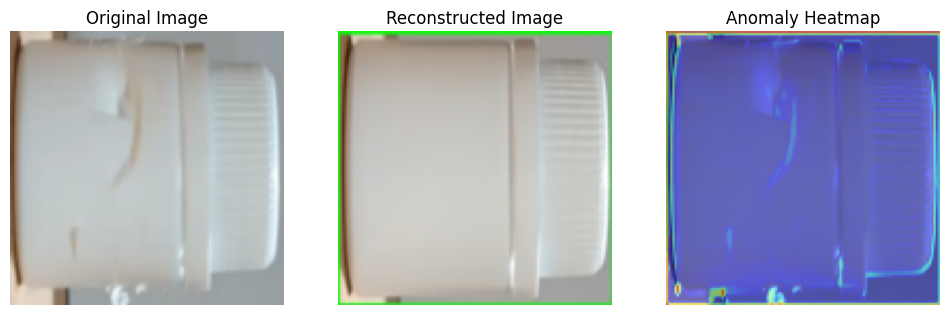

Reconstruction Error (MSE): 0.008029
Anomaly Detected: True


(0.008029039949178696, True)

In [7]:
image_path = "lampiran/cacat_1_input.png"
infer_anomaly_with_heatmap(image_path)

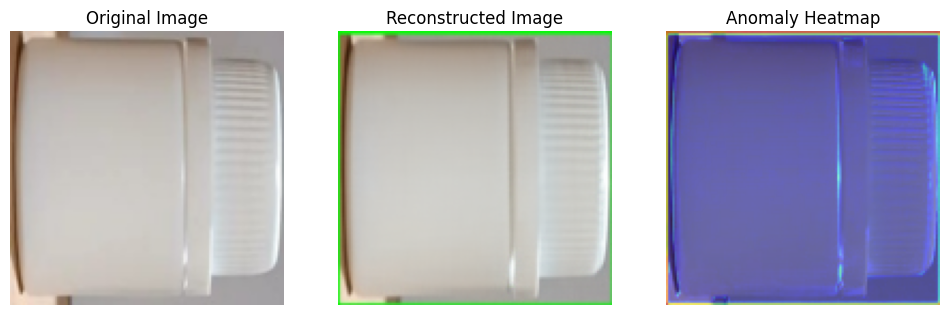

Reconstruction Error (MSE): 0.006447
Anomaly Detected: True


(0.006447288207709789, True)

In [31]:
image_path = "../cv2/crops/crop_1751266713611_0.jpg"
infer_anomaly_with_heatmap(image_path)